# LSTM with GloVe 6B 100d - Combined Data

This notebook trains a LSTM model to classify a news article into one of five bias labels using GloVe embeddings for each word in each article with an augmented data set that includes both the kaggle set and the data from our scrappers

## Import

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader           

from collections import Counter
from itertools import cycle
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_class_weight

import skorch
from skorch import NeuralNetClassifier
from skorch.dataset import ValidSplit
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from skorch.helper import predefined_split

from functools import partial

# Device setup
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

glove_file = 'glove.6B/glove.6B.100d.txt'
if not os.path.exists(glove_file):
    raise FileNotFoundError(f"{glove_file} not found. Please download it from https://nlp.stanford.edu/projects/glove/ and place it in your working directory.")

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We chose GloVe over word2vec as the pretrained model has larger vocab more robust, more reasons why here, over us training our own word2vec embedding with our limited sample of n<5000 

We chose the 6B model with 100 dimensions as we are running our models on local and our compute power is limited. 

In [2]:
# Load preprocessed data
train = pd.read_csv('data/combined_transformers_train_preprocessed.csv')
test = pd.read_csv('data/combined_transformers_test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Encode labels
y_train_raw = train['Bias']
y_test_raw = test['Bias']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

Number of classes: 5


In [3]:
# check 
train.head(5)

,Title,cleaned_text,Bias
0,Reminder: Trump is a demented criminal president,,left
1,Hamas Frees 4 Israeli Soldiers As Part Of Gaza...,"TEL AVIV, Israel (AP) - Four female Israeli so...",left
2,These Progressives Will Guide Us Through the D...,"Without a doubt, 2025 is going to be tough-but...",left
3,'It's a free country' - but some White House s...,White House staffers in the Office of Legislat...,left
4,VIDEO: 'Crazy' Winter Storm Forces Georgia Dri...,"A winter storm that hit the Atlanta, Georgia, ...",right


## Global Variables

In [4]:
batch_size = 32
criterion = nn.CrossEntropyLoss()
torch.manual_seed(42)
np.random.seed(42)

## Build Vocab and Embeddings

In [5]:
def tokenize(text):
    return text.lower().split()
    
def build_vocab(texts):
    vocab = Counter()
    for text in texts:
        tokens = tokenize(text)
        vocab.update(tokens)
    return vocab

def load_glove_embeddings(glove_file, vocab, embedding_dim):
    embeddings_index = {}
    with open(glove_file, 'r', encoding='utf8') as f:
        for line in f:
            parts = line.strip().split()
            # skip any malformed lines
            if len(parts) != embedding_dim + 1:
                continue
            word = parts[0]
            vector = np.asarray(parts[1:], dtype=np.float32)
            embeddings_index[word] = vector

    # Special tokens
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    pad_vec = np.zeros(embedding_dim, dtype=np.float32)
    unk_vec = np.random.normal(scale=0.6, size=(embedding_dim,)).astype(np.float32)

    # Build list of vectors
    embedding_list = [pad_vec, unk_vec]
    for word in sorted(vocab):
        word2idx[word] = len(word2idx)
        vec = embeddings_index.get(word)
        if vec is None:
            vec = np.random.normal(scale=0.6, size=(embedding_dim,)).astype(np.float32)
        embedding_list.append(vec)

    embedding_matrix = np.asarray(embedding_list, dtype=np.float32)  
    print("Embedding matrix shape:", embedding_matrix.shape)
    embedding_tensor = torch.from_numpy(embedding_matrix)      

    return word2idx, embedding_tensor, embeddings_index


We use simple white space tokenizer to use with GloVe which is word based to feed words sequentially into LSTM. 

In [6]:
def encode_text(texts, word2idx, max_len=128):
    encoded = []
    for text in texts:
        tokens = tokenize(text)
        idxs = [word2idx.get(token, word2idx['<UNK>']) for token in tokens]
        if len(idxs) < max_len:
            idxs += [word2idx['<PAD>']] * (max_len - len(idxs))
        else:
            idxs = idxs[:max_len]
        encoded.append(idxs)
    return torch.tensor(encoded)

In [7]:
vocab = build_vocab(train['cleaned_text'])        
embedding_dim = 100

word2idx, embedding_tensor, embeddings_index = load_glove_embeddings(glove_file, vocab, embedding_dim)

# check embedding match:
idx = word2idx.get('trump')
# check loaded embedding tensor directly
print("Loaded embedding tensor first 5 dims:", embedding_tensor[idx][:5])
# compare with original GloVe
print("Original GloVe vector first 5 dims:", embeddings_index['trump'][:5])

Embedding matrix shape: (82363, 100)
Loaded embedding tensor first 5 dims: tensor([-0.1573, -0.7550,  0.3684, -0.1896, -0.1690])
Original GloVe vector first 5 dims: [-0.15731 -0.75503  0.36845 -0.18958 -0.16896]


In [8]:
max_len = 128  # maximum number of tokens per article

# Encode texts to fixed‑length index tensors
X_train = encode_text(train['cleaned_text'], word2idx, max_len)
X_test = encode_text(test['cleaned_text'], word2idx, max_len)

# Convert label arrays to torch tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

class EncodedTextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.encodings[idx], self.labels[idx] 

# Create dataset instances
train_dataset = EncodedTextDataset(X_train, y_train_tensor)
test_dataset = EncodedTextDataset(X_test, y_test_tensor)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


Train batches: 107 | Test batches: 27


## LSTM

In [9]:
class LSTMModule(nn.Module):
    def __init__(self,
                 embedding_tensor,
                 hidden_dim=256,
                 num_layers=2,
                 bidirectional=True,
                 dropout=0.5,
                 num_classes=5):            
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor, freeze=True, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_tensor.size(1),
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1),
                            num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (h_n, _) = self.lstm(embedded)
        if self.bidirectional:
            feat = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            feat = h_n[-1]
        return self.fc(feat)

We do not train the GloVe embedding or SFT it for our use case by setting freeze=True and lock padding index so that padding stays at zero and cannot drift.

In [10]:
X_np = X_train.numpy()         
y_np = y_train_tensor.numpy()

In [11]:
# Handled imbalanced classes

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_np), y=y_np)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

In [12]:
#for debugging, setting this toggle to True means that the test set is included in validation set
USE_TEST_AS_VALID = False 

In [13]:
train_split = predefined_split(test_dataset) if USE_TEST_AS_VALID else ValidSplit(0.2, stratified=True)
    
net = NeuralNetClassifier(
    module=LSTMModule,
    module__embedding_tensor=embedding_tensor,
    criterion=partial(nn.CrossEntropyLoss, weight=class_weights_tensor),
    optimizer=torch.optim.Adam,
    lr=0.001,
    batch_size=16,
    max_epochs=6,
    device=device,
    train_split=train_split,
    callbacks=[
        EpochScoring(scoring='f1_weighted', name='train_f1', lower_is_better=False, on_train=True),
        EpochScoring(scoring='accuracy', name='train_acc', lower_is_better=False, on_train=True),
        
        EpochScoring(scoring='f1_weighted', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),

        LRScheduler(policy=ReduceLROnPlateau,
                   monitor='valid_f1',  
                   factor=0.5,
                   patience=5,
                   verbose=True),
        EarlyStopping(monitor='valid_f1', patience=5, lower_is_better=False)
    ]
    )

In [15]:
net.fit(X_train, y_train)

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr      dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  -------
      1       0.3314      0.3636        1.5263       0.4482      0.4703        1.4190  0.0010  20.3316
      2       0.4425      0.4733        1.3159       0.4949      0.5144        1.3253  0.0010  11.6644
      3       0.5385      0.5595        1.1156       0.5664      0.5811        1.1510  0.0010  14.9355
      4       0.6511      0.6612        0.8217       0.6175      0.6291        1.1281  0.0010  11.9924
      5       0.7347      0.7397        0.5950       0.6423      0.6539        0.9932  0.0010  12.0085
      6       0.8392      0.8407        0.3304       0.7007      0.7035        1.0221  0.0010  11.9854


<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LSTMModule(
    (embedding): Embedding(82363, 100, padding_idx=0)
    (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
    (fc): Linear(in_features=512, out_features=5, bias=True)
  ),
)

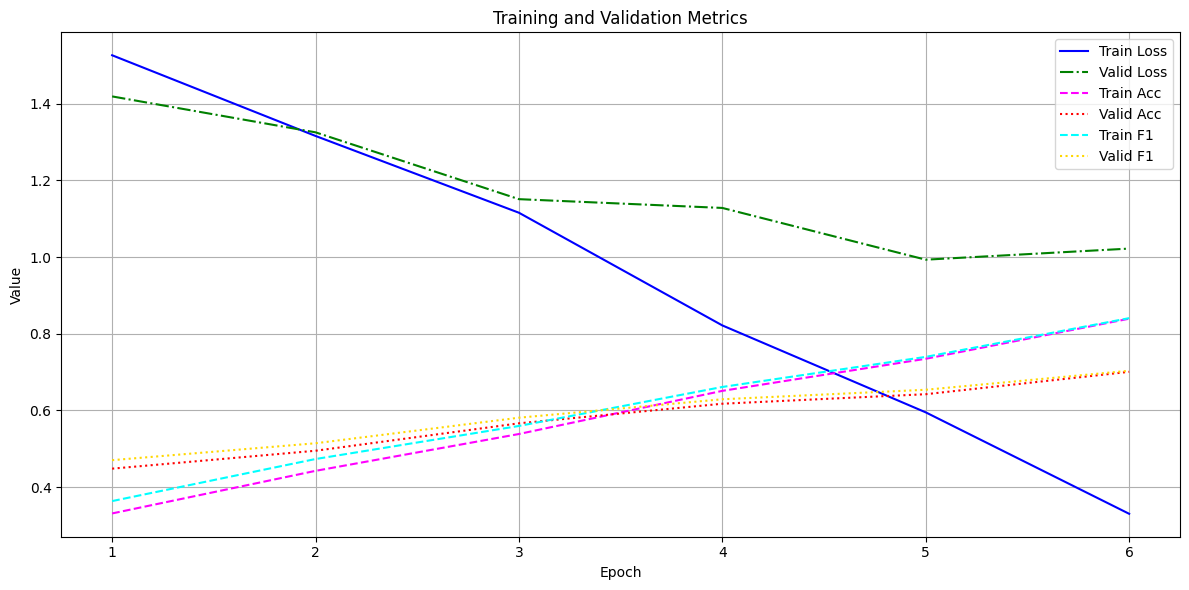

In [18]:
def plot_lstm_learning_curves(net):
    """
    Plot training and validation metrics for the LSTM model on a single chart.
    """
    history = net.history
    
    plt.figure(figsize=(12, 6))
    epochs = len(history)
    x_axis = range(1, epochs+1)
    
    # Plot all metrics on the same chart
    plt.plot(x_axis, [h['train_loss'] for h in history], label='Train Loss', color='blue')
    plt.plot(x_axis, [h.get('valid_loss', float('nan')) for h in history], label='Valid Loss', color='green', linestyle='-.')
    plt.plot(x_axis, [h.get('train_acc', float('nan')) for h in history], label='Train Acc', color='magenta', linestyle='--')
    plt.plot(x_axis, [h.get('valid_acc', float('nan')) for h in history], label='Valid Acc', color='red', linestyle=':')
    plt.plot(x_axis, [h.get('train_f1', float('nan')) for h in history], label='Train F1', color='cyan', linestyle='--')
    plt.plot(x_axis, [h.get('valid_f1', float('nan')) for h in history], label='Valid F1', color='gold', linestyle=':')
    
    plt.title('Training and Validation Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Call this with the best LSTM model found
plot_lstm_learning_curves(net)

With the same parameters as the earlier run, we can see that training can actually continue for longer with the augmented dataset as the model has not shown signs of strong overfitting while loss and performance metrics are all continuing to improve. 


### Train LSTM with Best Params

## Evaluation

In [19]:
y_pred = net.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4)

print(f"LSTM Accuracy: {acc * 100:.2f}%")
print(f"LSTM Weighted F1-score: {f1:.4f}")
print("\nClassification Report:\n", report)

LSTM Accuracy: 66.51%
LSTM Weighted F1-score: 0.6708

Classification Report:
               precision    recall  f1-score   support

      center     0.5299    0.7470    0.6200        83
   lean left     0.4906    0.6290    0.5512       124
  lean right     0.6119    0.5694    0.5899        72
        left     0.8138    0.7067    0.7565       433
       right     0.6014    0.5724    0.5866       145

    accuracy                         0.6651       857
   macro avg     0.6095    0.6449    0.6208       857
weighted avg     0.6867    0.6651    0.6708       857



### Classification Report Commentary 

Large improvements are seen in all metrics. Precision, recall and f1 values for all classes improved. Accuracy also rose from 0.3776 to 0.6651 while weighted f1 rose from 0.4146 to 0.6708


### Confusion Matrices

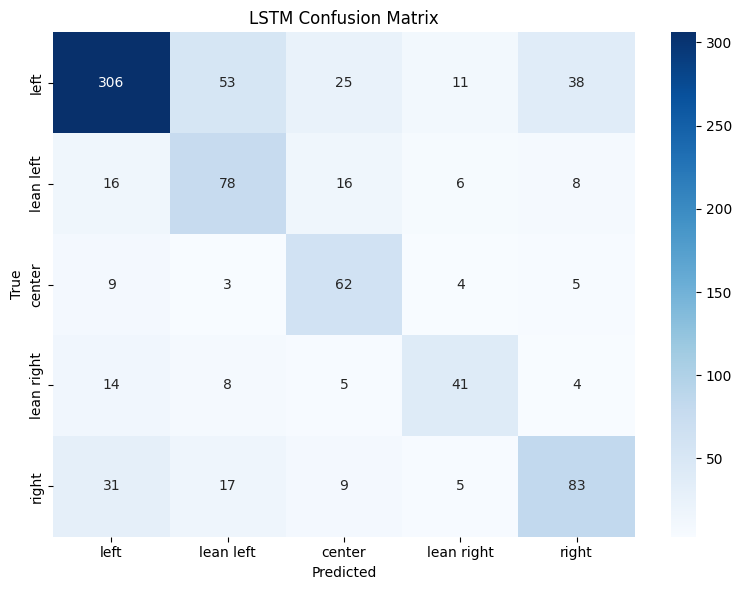

In [21]:
X_test_np = X_test.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()
y_pred = net.predict(X_test_np)

label_order = ['left', 'lean left', 'center', 'lean right', 'right']
label_indices = [np.where(label_encoder.classes_ == label)[0][0] for label in label_order]

cm = confusion_matrix(y_test_np, y_pred, labels=label_indices)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LSTM Confusion Matrix')
plt.tight_layout()
plt.show()

- The addition of the new data helped the model to learn distinctions and the issue of confusion between the extremes of the bias spectrum has been resovled. The diagonal performance is also strongest now though there remains some issues with flushing to the left (right predicted as left and left predicted as lean left)

In [23]:
classes = net.classes_  # Replacing best_net with trained net
class_names = label_encoder.classes_  # Should be in correct index order

for i, class_idx in enumerate(classes):
    # Use class_idx directly to map to string label
    class_label = class_names[class_idx]

    # One-vs-rest encoding
    y_true_binary = (y_test_np == class_idx).astype(int)
    y_pred_binary = (y_pred == class_idx).astype(int)

    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print(f"\nOne-vs-Rest Confusion Matrix for class '{class_label}':")
    print(cm)


One-vs-Rest Confusion Matrix for class 'center':
[[719  55]
 [ 21  62]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[652  81]
 [ 46  78]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[759  26]
 [ 31  41]]

One-vs-Rest Confusion Matrix for class 'left':
[[354  70]
 [127 306]]

One-vs-Rest Confusion Matrix for class 'right':
[[657  55]
 [ 62  83]]


## ROC-AUC

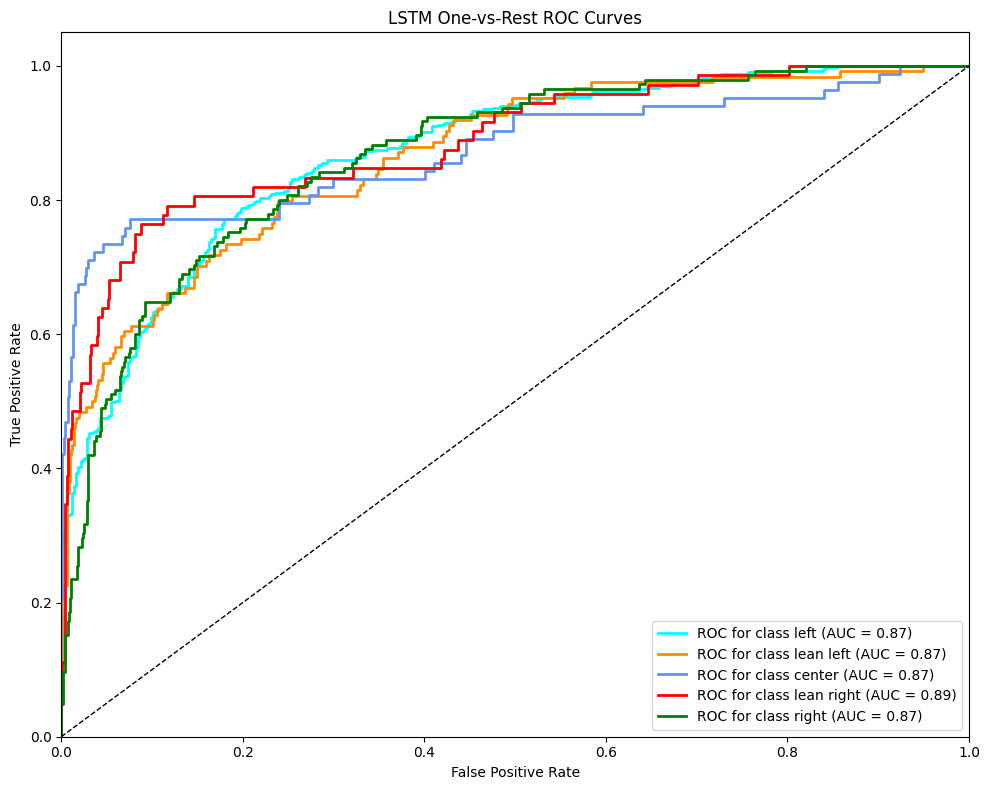

In [24]:
label_order = ['left', 'lean left', 'center', 'lean right', 'right']
class_names = label_encoder.classes_

# Map label_order strings to corresponding class indices
label_to_index = {label: np.where(class_names == label)[0][0] for label in label_order}

X_test_np = X_test.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()
classes = net.classes_

# Binarize test labels using class indices
y_test_binarized = label_binarize(y_test_np, classes=classes)
y_score = net.predict_proba(X_test_np)

fpr = dict()
tpr = dict()
roc_auc = dict()

for label in label_order:
    idx = label_to_index[label]
    fpr[label], tpr[label], _ = roc_curve(y_test_binarized[:, idx], y_score[:, idx])
    roc_auc[label] = roc_auc_score(y_test_binarized[:, idx], y_score[:, idx])

# Plotting
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green'])

for label, color in zip(label_order, colors):
    plt.plot(fpr[label], tpr[label], color=color, lw=2,
             label=f'ROC for class {label} (AUC = {roc_auc[label]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM One-vs-Rest ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [25]:
macro_auc = roc_auc_score(y_test_binarized, y_score, average='weighted')
print(f"Macro-average ROC AUC: {macro_auc:.4f}")

Macro-average ROC AUC: 0.8714


ROC-AUC values for the LSTM rose from a floor of 0.63 to 0.87 and a ceiling of 0.72 to a ceiling of 0.89.  

The macro-average ROC-AUC also improved from 0.6768 to 0.8714 showing a much stronger learning of the class boundaries by the model. 

Even without retraining and retuning LSTM, we can see with the frozen parameters that class seperability has improved significantly. 

## Final Conclusion 

### Key Observations


<img src="images/LSTM_perf.png" width="700">

There is a massive improvement in the performance scores even with the modest addition to the dataset. This suggests that sequential information and word order are highly relevant features for this classification task. With the expanded dataset, LSTM could leverage the additional contextual information, while the FFNN did not capture these patterns from averaged embeddings.

Further, additional data is advantageous for the architecture of LSTMs as the LSTMs can utilise the memory and context cells to retain important information and forget irrelevant details, which is crucial for understanding text.